## Projet Analyse de données

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv('games.csv')
print(df.head())


                                         AppID          Name Release date  \
2539430             Black Dragon Mage Playtest   Aug 1, 2023        0 - 0   
496350   Supipara - Chapter 1 Spring Has Come!  Jul 29, 2016    0 - 20000   
1034400      Mystery Solitaire The Black Raven   May 6, 2019    0 - 20000   
3292190            버튜버 파라노이아 - Vtuber Paranoia  Oct 31, 2024    0 - 20000   
3631080                          Maze Quest VR  Apr 24, 2025    0 - 20000   

         Estimated owners  Peak CCU  Required age  Price  DiscountDLC count  \
2539430                 0         0          0.00      0                  0   
496350                  0         0          5.24     65                  0   
1034400                 0         0          4.99      0                  0   
3292190                 1         0          8.99      0                  1   
3631080                 0         0          4.99      0                  0   

                                            About the game  \


In [2]:
df.dtypes

AppID                             str
Name                              str
Release date                      str
Estimated owners                int64
Peak CCU                        int64
Required age                  float64
Price                           int64
DiscountDLC count               int64
About the game                    str
Supported languages               str
Full audio languages              str
Reviews                           str
Header image                      str
Website                           str
Support url                       str
Support email                     str
Windows                          bool
Mac                              bool
Linux                            bool
Metacritic score                int64
Metacritic url                    str
User score                      int64
Positive                        int64
Negative                        int64
Score rank                    float64
Achievements                    int64
Recommendati

In [3]:
df.describe()

,Estimated owners,Peak CCU,Required age,Price,DiscountDLC count,Metacritic score,User score,Positive,Negative,Score rank,Achievements,Recommendations,Average playtime forever,Average playtime two weeks,Median playtime forever,Median playtime two weeks,Movies
count,1.226110e+05,122611.000000,122611.000000,122611.000000,122611.000000,122611.000000,122611.000000,1.226110e+05,1.226110e+05,40.000000,122611.000000,1.226110e+05,1.226110e+05,122611.000000,1.226110e+05,122611.000000,0.0
mean,5.459332e+01,0.167611,4.765091,18.353663,0.545856,2.564941,0.024549,1.044986e+03,1.691974e+02,99.175000,18.087015,9.618250e+02,2.080232e+02,13.789268,1.735705e+02,14.722170,NaN
std,3.729452e+03,1.653591,12.531030,28.858970,14.516026,13.660559,1.394901,2.809173e+04,5.374645e+03,0.675107,141.493879,2.187880e+04,1.121768e+04,270.378053,1.120254e+04,294.509615,NaN
min,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,98.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000,NaN
25%,0.000000e+00,0.000000,0.550000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,99.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000,NaN
50%,0.000000e+00,0.000000,2.240000,0.000000,0.000000,0.000000,0.000000,5.000000e+00,1.000000e+00,99.000000,2.000000,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000,NaN
75%,0.000000e+00,0.000000,5.240000,40.000000,0.000000,0.000000,0.000000,3.700000e+01,1.000000e+01,100.000000,19.000000,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000,NaN
max,1.013936e+06,21.000000,999.980000,100.000000,3703.000000,97.000000,100.000000,7.642084e+06,1.173003e+06,100.000000,9821.000000,4.830455e+06,3.429544e+06,20088.000000,3.429544e+06,20088.000000,NaN


## Analyse unidimensionnelles


--- Début de l'Analyse Unidimensionnelle ---

[1] Analyse du support OS...


C:\Users\eliot\AppData\Local\Temp\ipykernel_12664\3691424617.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=os_counts.index, y=os_counts.values, palette=['#3498db', '#95a5a6', '#f39c12'])


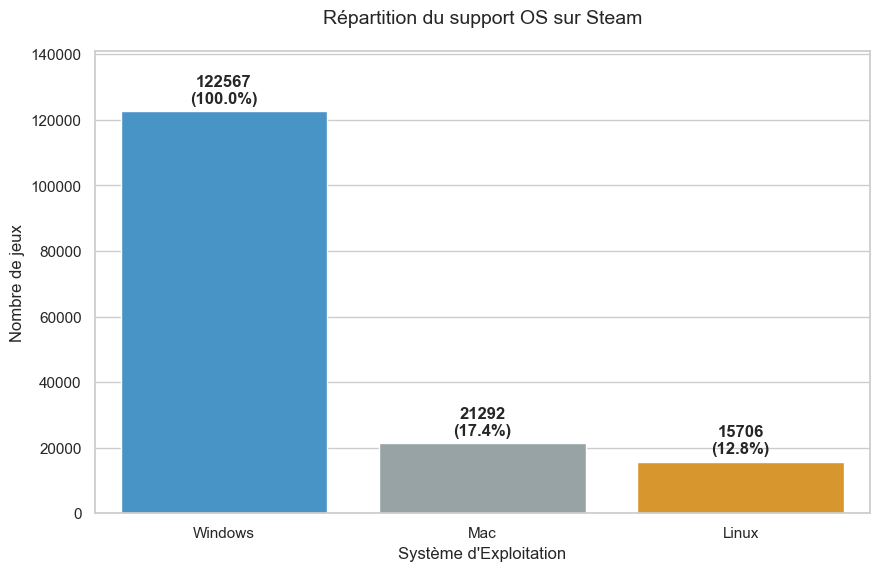


[2] Traitement de la chronologie...
Attention : Les dates n'ont pas pu être converties correctement.

[3] Visualisation des Outliers (Variables de succès et Prix)...


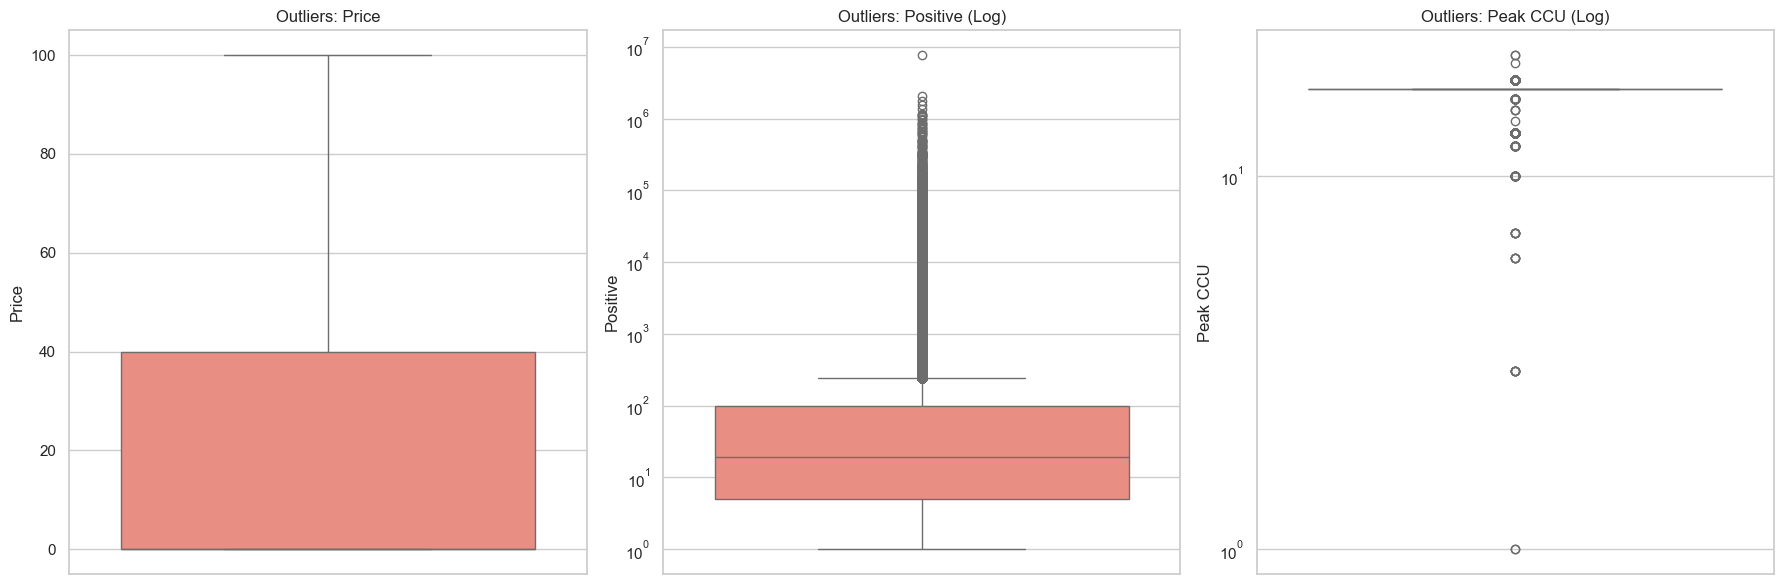


[4] Analyse des distributions (Echelles log)...


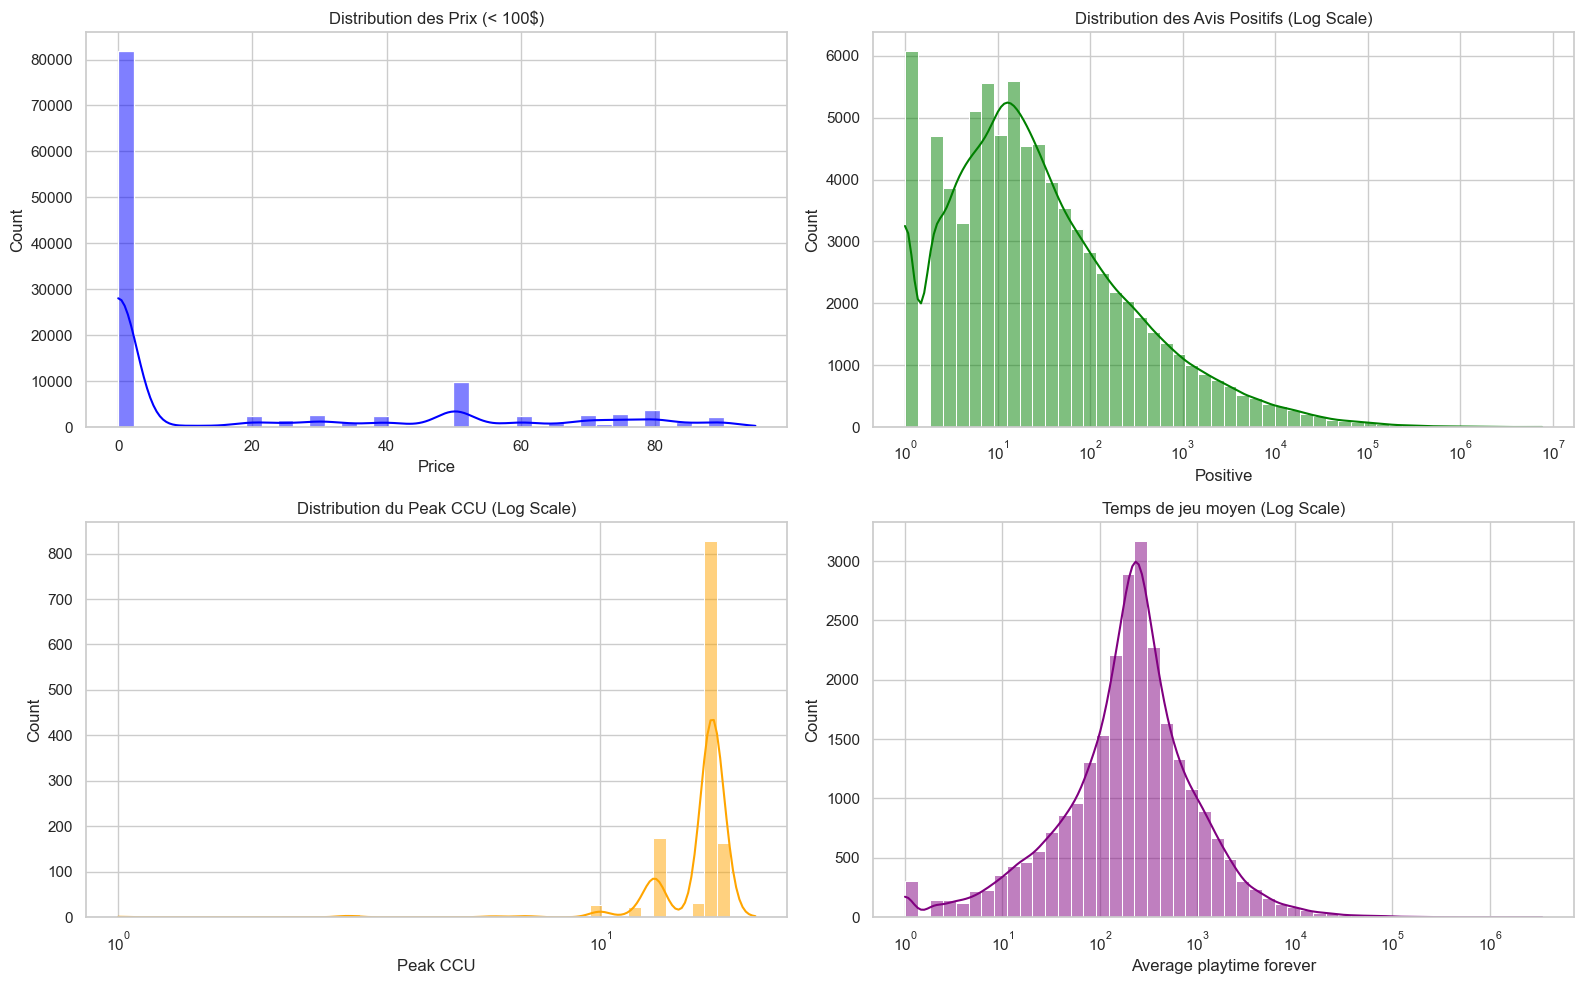


[6] Top 10 des Genres...


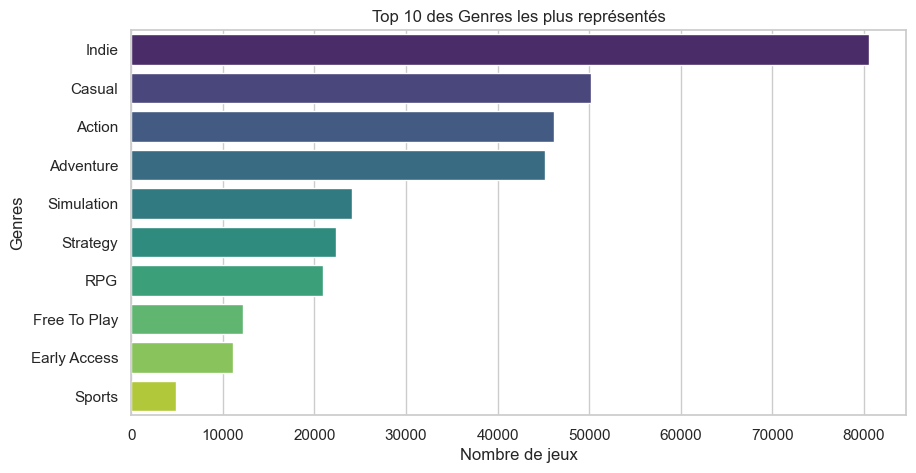

In [10]:
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

def analyse_unidimensionnelle_complete_steam(df):
    print("--- Début de l'Analyse Unidimensionnelle ---")
    
    df.columns = df.columns.str.strip()

    print("\n[1] Analyse du support OS...")
    os_cols = ['Windows', 'Mac', 'Linux']
    present_os = [c for c in os_cols if c in df.columns]
    
    if present_os:
        os_counts = df[present_os].sum().sort_values(ascending=False)
        plt.figure(figsize=(10, 6))
        
        
        ax = sns.barplot(x=os_counts.index, y=os_counts.values, palette=['#3498db', '#95a5a6', '#f39c12'])
        
        
        total_games = len(df)
        for i, v in enumerate(os_counts.values):
            percentage = (v / total_games) * 100
            ax.text(i, v + (max(os_counts.values) * 0.02), 
                    f"{int(v)}\n({percentage:.1f}%)", 
                    ha='center', fontweight='bold')

        plt.title("Répartition du support OS sur Steam", fontsize=14, pad=20)
        plt.ylabel("Nombre de jeux")
        plt.xlabel("Système d'Exploitation")
        plt.ylim(0, max(os_counts.values) * 1.15) 
        plt.show()

    print("\n[2] Traitement de la chronologie...")
    df['Release date clean'] = pd.to_datetime(df['Release date'], errors='coerce')
    years = df['Release date clean'].dt.year
    valid_years = years[(years >= 2003) & (years <= 2026)]
    
    if not valid_years.empty:
        plt.figure(figsize=(10, 5))
        valid_years.value_counts().sort_index().plot(kind='line', marker='o', color='crimson', linewidth=2)
        plt.title("Évolution du nombre de sorties sur Steam")
        plt.xlabel("Année")
        plt.ylabel("Nombre de jeux")
        plt.show()
    else:
        print("Attention : Les dates n'ont pas pu être converties correctement.")

    print("\n[3] Visualisation des Outliers (Variables de succès et Prix)...")
    outlier_features = ['Price', 'Positive', 'Peak CCU', 'DLC count']
    cols_to_plot = [c for c in outlier_features if c in df.columns]
    
    if cols_to_plot:
        fig, axes = plt.subplots(1, len(cols_to_plot), figsize=(18, 6))
        for i, col in enumerate(cols_to_plot):
            if col in ['Positive', 'Peak CCU']:
                sns.boxplot(y=df[df[col] > 0][col], ax=axes[i], color='salmon')
                axes[i].set_yscale('log')
                axes[i].set_title(f'Outliers: {col} (Log)')
            else:
                sns.boxplot(y=df[col], ax=axes[i], color='salmon')
                axes[i].set_title(f'Outliers: {col}')
        plt.tight_layout()
        plt.show()

    print("\n[4] Analyse des distributions (Echelles log)...")
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    
    sns.histplot(df[df['Price'] < 100]['Price'], bins=40, kde=True, ax=axes[0,0], color='blue')
    axes[0,0].set_title('Distribution des Prix (< 100$)')

    sns.histplot(df[df['Positive'] > 0]['Positive'], bins=50, kde=True, log_scale=True, ax=axes[0,1], color='green')
    axes[0,1].set_title('Distribution des Avis Positifs (Log Scale)')

    sns.histplot(df[df['Peak CCU'] > 0]['Peak CCU'], bins=50, kde=True, log_scale=True, ax=axes[1,0], color='orange')
    axes[1,0].set_title('Distribution du Peak CCU (Log Scale)')


    sns.histplot(df[df['Average playtime forever'] > 0]['Average playtime forever'], bins=50, kde=True, log_scale=True, ax=axes[1,1], color='purple')
    axes[1,1].set_title('Temps de jeu moyen (Log Scale)')
    
    plt.tight_layout()
    plt.show()


    print("\n[6] Top 10 des Genres...")
    if 'Genres' in df.columns:
        top_genres = df['Genres'].str.split(',').explode().str.strip().value_counts().head(10)
        plt.figure(figsize=(10, 5))
        sns.barplot(x=top_genres.values, y=top_genres.index, hue=top_genres.index, palette='viridis', legend=False)
        plt.title("Top 10 des Genres les plus représentés")
        plt.xlabel("Nombre de jeux")
        plt.show()

analyse_unidimensionnelle_complete_steam(df)

## Analyse multidimensionnelle 


--- Analyse Multidimensionnelle : Matrice de Corrélation ---


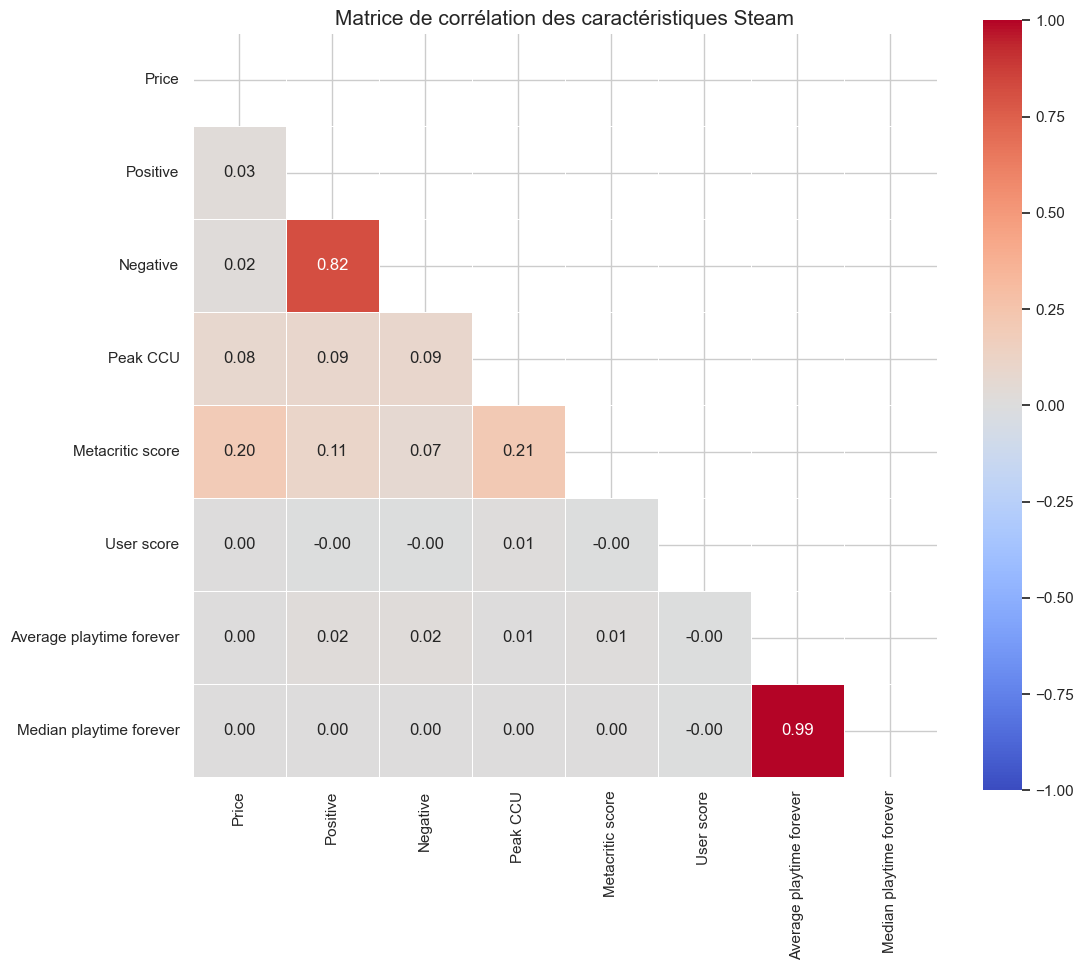

In [18]:
def plot_correlation_matrix(df):
    print("\n--- Analyse Multidimensionnelle : Matrice de Corrélation ---")
    
    cols_etude = [
        'Price', 'Positive', 'Negative', 'Peak CCU', 
        'Metacritic score', 'User score', 'DLC count',
        'Average playtime forever', 'Median playtime forever'
    ]
    
    
    cols_etude = [c for c in cols_etude if c in df.columns]
    
    
    corr = df[cols_etude].corr()
    
    
    plt.figure(figsize=(12, 10))
    mask = np.triu(np.ones_like(corr, dtype=bool)) 
    
    sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap='coolwarm', 
                vmin=-1, vmax=1, center=0, square=True, linewidths=.5)
    
    plt.title("Matrice de corrélation des caractéristiques Steam", fontsize=15)
    plt.show()


plot_correlation_matrix(df)